# Baseline Classifier Vergleich

In diesem Notebook werden die Ergebnisse der drei Baseline Classifier (KNN, Logistic Regression, Naive Bayes) über alle drei Datensätze (Telco Churn, E-Commerce, Bank Marketing) verglichen.

Die Werte wurden direkt aus den jeweiligen Base-Notebooks übernommen:
- `knn_analysis.ipynb`
- `logreg_analysis.ipynb`
- `bayesfin.ipynb`

## 1. Imports

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Ergebnisse der Baseline Classifier

Alle 3 Baseline Classifier wurden mit dem random_state = 42 ausgeführt sind also hier consistent

In [ ]:
# Ergebnisse direkt aus den Base-Notebooks übernommen
# Quellen: knn_analysis.ipynb , logreg_analysis.ipynb, bayesfin.ipynb

rows = [
    # Telco Churn
    {'Dataset': 'Telco Churn',    'Classifier': 'KNN',                 'Train Accuracy': 0.7138, 'Valid Accuracy': 0.7194, 'Mean CV Score': 0.7391},
    {'Dataset': 'Telco Churn',    'Classifier': 'Logistic Regression', 'Train Accuracy': 0.8021, 'Valid Accuracy': 0.8190, 'Mean CV Score': 0.8021},
    {'Dataset': 'Telco Churn',    'Classifier': 'Naive Bayes',         'Train Accuracy': 0.7167, 'Valid Accuracy': 0.7040, 'Mean CV Score': 0.7151},
    # E-Commerce
    {'Dataset': 'E-Commerce',     'Classifier': 'KNN',                 'Train Accuracy': 0.9112, 'Valid Accuracy': 0.8864, 'Mean CV Score': 0.8875},
    {'Dataset': 'E-Commerce',     'Classifier': 'Logistic Regression', 'Train Accuracy': 0.8819, 'Valid Accuracy': 0.8902, 'Mean CV Score': 0.8815},
    {'Dataset': 'E-Commerce',     'Classifier': 'Naive Bayes',         'Train Accuracy': 0.8588, 'Valid Accuracy': 0.8599, 'Mean CV Score': 0.8576},
    # Bank Marketing
    {'Dataset': 'Bank Marketing', 'Classifier': 'KNN',                 'Train Accuracy': 0.9024, 'Valid Accuracy': 0.8935, 'Mean CV Score': 0.8906},
    {'Dataset': 'Bank Marketing', 'Classifier': 'Logistic Regression', 'Train Accuracy': 0.9128, 'Valid Accuracy': 0.9042, 'Mean CV Score': 0.9119},
    {'Dataset': 'Bank Marketing', 'Classifier': 'Naive Bayes',         'Train Accuracy': 0.8783, 'Valid Accuracy': 0.8804, 'Mean CV Score': 0.8782},
]

results_df = pd.DataFrame(rows)
display(results_df.set_index(['Dataset', 'Classifier']))

Train Accuracy  Valid Accuracy  \
Dataset        Classifier                                            
Telco Churn    KNN                          0.7138          0.7194   
               Logistic Regression          0.8021          0.8190   
               Naive Bayes                  0.7167          0.7040   
E-Commerce     KNN                          0.9112          0.8864   
               Logistic Regression          0.8819          0.8902   
               Naive Bayes                  0.8588          0.8599   
Bank Marketing KNN                          0.9024          0.8935   
               Logistic Regression          0.9128          0.9042   
               Naive Bayes                  0.8783          0.8804   

                                    Mean CV Score  
Dataset        Classifier                          
Telco Churn    KNN                         0.7391  
               Logistic Regression         0.8021  
               Naive Bayes                 0.7151  
E-Commerce     KNN                         0.8875  
               Logistic Regression         0.8815  
               Naive Bayes                 0.8576  
Bank Marketing KNN                         0.8906  
               Logistic Regression         0.9119  
               Naive Bayes                 0.8782

## 3. Vergleich: Validation Accuracy pro Dataset

In [16]:
pivot = results_df.pivot(index='Dataset', columns='Classifier', values='Valid Accuracy')
print("Validation Accuracy Vergleich:")
display(pivot)

Validation Accuracy Vergleich:


Classifier,KNN,Logistic Regression,Naive Bayes
Dataset,,,
Bank Marketing,0.8935,0.9042,0.8804
E-Commerce,0.8864,0.8902,0.8599
Telco Churn,0.7194,0.8190,0.7040


## 4. Visualisierung

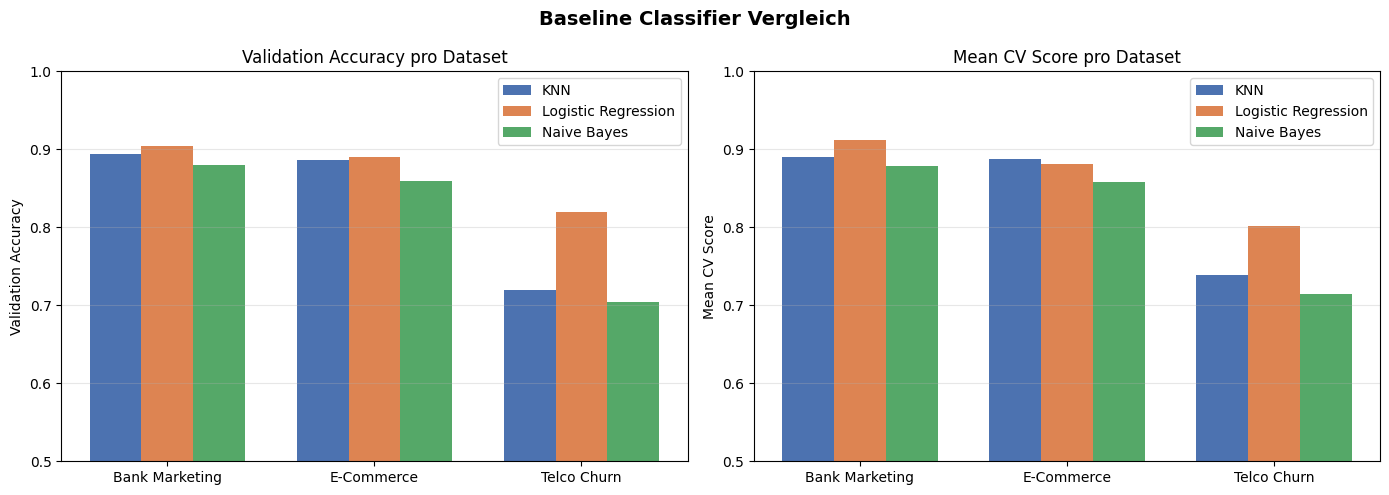

In [17]:
clf_names = ['KNN', 'Logistic Regression', 'Naive Bayes']
colors     = ['#4C72B0', '#DD8452', '#55A868']
x          = np.arange(len(pivot))
width      = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Balkendiagramm: Valid Accuracy
for i, (clf, color) in enumerate(zip(clf_names, colors)):
    axes[0].bar(x + i * width, pivot[clf], width, label=clf, color=color)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(pivot.index)
axes[0].set_ylabel('Validation Accuracy')
axes[0].set_title('Validation Accuracy pro Dataset')
axes[0].legend()
axes[0].set_ylim(0.5, 1.0)
axes[0].grid(axis='y', alpha=0.3)

# Balkendiagramm: Mean CV Score
pivot_cv = results_df.pivot(index='Dataset', columns='Classifier', values='Mean CV Score')
for i, (clf, color) in enumerate(zip(clf_names, colors)):
    axes[1].bar(x + i * width, pivot_cv[clf], width, label=clf, color=color)
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(pivot_cv.index)
axes[1].set_ylabel('Mean CV Score')
axes[1].set_title('Mean CV Score pro Dataset')
axes[1].legend()
axes[1].set_ylim(0.5, 1.0)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Baseline Classifier Vergleich', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Durchschnittlicher Vergleich pro Classifier

In [18]:
avg_df = (
    results_df
    .groupby('Classifier')[['Train Accuracy', 'Valid Accuracy', 'Mean CV Score']]
    .mean()
    .round(4)
    .sort_values('Valid Accuracy', ascending=False)
)

print("Durchschnittliche Performance pro Classifier (über alle 3 Datasets):")
display(avg_df)

Durchschnittliche Performance pro Classifier (über alle 3 Datasets):


,Train Accuracy,Valid Accuracy,Mean CV Score
Classifier,,,
Logistic Regression,0.8656,0.8711,0.8652
KNN,0.8425,0.8331,0.8391
Naive Bayes,0.8179,0.8148,0.8170


## 6. Fazit

Der Vergleich der drei Baseline Classifier über alle Datensätze zeigt ein klares Bild: **Logistic Regression** schneidet konsistent am besten ab und erzielt mit einer durchschnittlichen Validation Accuracy von **87.11%** das stärkste Ergebnis.

Besonders deutlich wird der Vorsprung beim Telco-Datensatz, wo Logistic Regression mit **81.90%** gegenüber KNN (71.94%) und Naive Bayes (70.40%) deutlich führt. Dieser Unterschied lässt sich darauf zurückführen, dass Logistic Regression besonders gut mit vielen binären Features umgeht, wie sie durch One-Hot-Encoding entstehen, und zusätzlich durch GridSearchCV auf den optimalen Regularisierungsparameter C abgestimmt wurde.

**KNN** belegt den zweiten Platz mit einer durchschnittlichen Accuracy von **83.31%**, leidet jedoch darunter das bei vielen Features die Aussagekraft von Distanzmaßen abnimmt. Durch die Feature Selection (SelectPercentile, 10%) auf nur 3–5 Features wird dieses Problem teilweise abgemildert.

**Naive Bayes** performt mit **81.48%** am schwächsten, was auf die Unabhängigkeitsannahme zurückzuführen ist: Das Modell geht davon aus, dass alle Features voneinander unabhängig sind, das ist eine Annahme, die bei den vorliegenden Datensätzen nicht erfüllt ist (z. B. hängen `Contract` und `tenure` im Telco-Datensatz stark zusammen).

Insgesamt zeigt der Bank-Marketing-Datensatz die höchsten Accuracy-Werte über alle Classifier, während Telco Churn die größte Herausforderung darstellt. Was naturlich Sinn macht da Bank-Marketing der größte und Telco der kleinste unserer Datensätze sind.